In [17]:
DATA_PATH = "../data/creditcard.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

df.head()

Dataset loaded successfully!
Dataset shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [18]:
# Basic information about the dataset

print("Dataset Information:")
print("--------------------")

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum().sum())

Dataset Information:
--------------------
Number of rows: 284807
Number of columns: 31

Column names:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Data types:
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

Missing values:
0


In [19]:
# Check the distribution of Normal and Fraud transactions

class_counts = df["Class"].value_counts()

print("Transaction Class Distribution:")
print(class_counts)

print("\nPercentage Distribution:")
print(df["Class"].value_counts(normalize=True) * 100)

Transaction Class Distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Percentage Distribution:
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


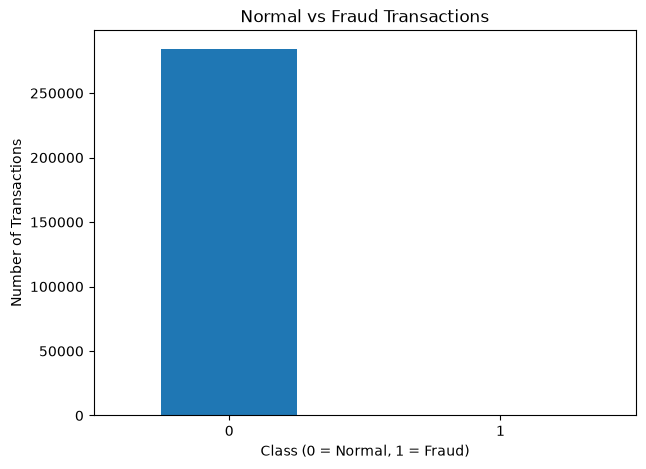

In [20]:
# Visualize class imbalance

plt.figure(figsize=(7, 5))

class_counts.plot(kind="bar")

plt.title("Normal vs Fraud Transactions")
plt.xlabel("Class (0 = Normal, 1 = Fraud)")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=0)

plt.show()

In [21]:
# Analyze transaction Amount

print("Amount Statistics:")
print(df["Amount"].describe())

Amount Statistics:
count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64


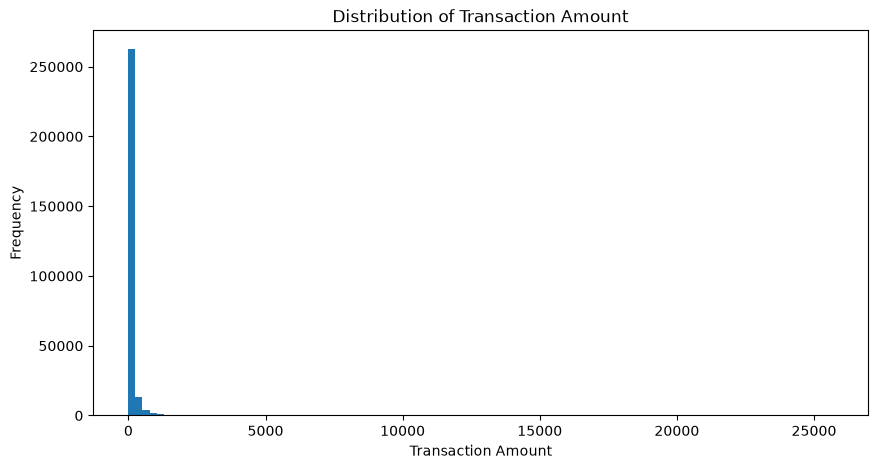

In [22]:
plt.figure(figsize=(10, 5))

plt.hist(df["Amount"], bins=100)

plt.title("Distribution of Transaction Amount")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")

plt.show()

In [23]:
# Analyze transaction Time

print("Time Statistics:")
print(df["Time"].describe())

Time Statistics:
count    284807.000000
mean      94813.859575
std       47488.145955
min           0.000000
25%       54201.500000
50%       84692.000000
75%      139320.500000
max      172792.000000
Name: Time, dtype: float64


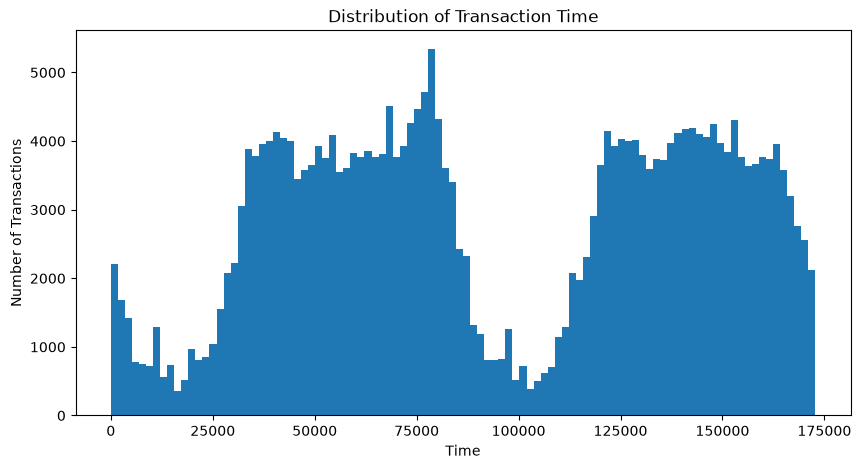

In [24]:
plt.figure(figsize=(10, 5))

plt.hist(df["Time"], bins=100)

plt.title("Distribution of Transaction Time")
plt.xlabel("Time")
plt.ylabel("Number of Transactions")

plt.show()

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.decomposition import PCA
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve
)

print("All libraries imported successfully!")

All libraries imported successfully!


In [26]:
# ============================================
# DATA PREPROCESSING - ROBUST SCALING
# ============================================

# Separate features and target
X = df.drop("Class", axis=1)
y = df["Class"]

print("Original feature shape:", X.shape)
print("Target shape:", y.shape)

# Create RobustScaler
scaler = RobustScaler()

# Scale the Amount feature
X["Amount"] = scaler.fit_transform(X[["Amount"]])

print("\nAmount feature after Robust Scaling:")
print(X["Amount"].describe())

Original feature shape: (284807, 30)
Target shape: (284807,)

Amount feature after Robust Scaling:
count    284807.000000
mean          0.927124
std           3.495006
min          -0.307413
25%          -0.229162
50%           0.000000
75%           0.770838
max         358.683155
Name: Amount, dtype: float64


In [27]:
# ============================================
# PREPARE DATA FOR ANOMALY DETECTION
# ============================================

X_normal = X[y == 0]
X_fraud = X[y == 1]

print("Normal transactions:", X_normal.shape)
print("Fraud transactions:", X_fraud.shape)

print("\nData prepared successfully!")

Normal transactions: (284315, 30)
Fraud transactions: (492, 30)

Data prepared successfully!


In [28]:
# ============================================
# ISOLATION FOREST
# ============================================

import time

print("Training Isolation Forest...")

start_time = time.time()

isolation_forest = IsolationForest(
    n_estimators=100,
    contamination=0.01,
    random_state=42,
    n_jobs=-1
)

isolation_forest.fit(X_normal)

training_time = time.time() - start_time

print("Isolation Forest training completed!")
print(f"Training time: {training_time:.2f} seconds")

Training Isolation Forest...
Isolation Forest training completed!
Training time: 7.58 seconds


In [29]:
# ============================================
# ISOLATION FOREST PREDICTIONS
# ============================================

print("Generating predictions...")

# Predict on the complete dataset
#  1  = normal
# -1  = anomaly
isolation_predictions = isolation_forest.predict(X)

# Convert predictions:
# Normal  -> 0
# Anomaly -> 1
isolation_predictions = np.where(isolation_predictions == -1, 1, 0)

print("Predictions generated successfully!")

print("\nPrediction distribution:")
print(pd.Series(isolation_predictions).value_counts())

Generating predictions...
Predictions generated successfully!

Prediction distribution:
0    281689
1      3118
Name: count, dtype: int64


In [30]:
# ============================================
# EVALUATE ISOLATION FOREST
# ============================================

precision_if = precision_score(y, isolation_predictions)
recall_if = recall_score(y, isolation_predictions)
f1_if = f1_score(y, isolation_predictions)

print("ISOLATION FOREST PERFORMANCE")
print("============================")
print(f"Precision: {precision_if:.4f}")
print(f"Recall:    {recall_if:.4f}")
print(f"F1-Score:  {f1_if:.4f}")

print("\nClassification Report:")
print(classification_report(
    y,
    isolation_predictions,
    target_names=["Normal", "Fraud"]
))

ISOLATION FOREST PERFORMANCE
Precision: 0.0879
Recall:    0.5569
F1-Score:  0.1518

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.99      0.99    284315
       Fraud       0.09      0.56      0.15       492

    accuracy                           0.99    284807
   macro avg       0.54      0.77      0.57    284807
weighted avg       1.00      0.99      0.99    284807



In [31]:
# ============================================
# ISOLATION FOREST CONFUSION MATRIX
# ============================================

cm_if = confusion_matrix(y, isolation_predictions)

print("Confusion Matrix:")
print(cm_if)

Confusion Matrix:
[[281471   2844]
 [   218    274]]


In [32]:
# ============================================
# LOCAL OUTLIER FACTOR (LOF)
# ============================================

import time

print("Training Local Outlier Factor...")

start_time = time.time()

lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.01,
    novelty=True,
    n_jobs=-1
)

lof.fit(X_normal)

lof_training_time = time.time() - start_time

print("LOF training completed!")
print(f"Training time: {lof_training_time:.2f} seconds")

Training Local Outlier Factor...
LOF training completed!
Training time: 694.76 seconds


In [33]:
# ============================================
# LOF PREDICTIONS
# ============================================

print("Generating LOF predictions...")

# LOF returns:
#  1  = normal
# -1  = anomaly

lof_predictions = lof.predict(X)

# Convert:
# Normal  -> 0
# Anomaly -> 1
lof_predictions = np.where(lof_predictions == -1, 1, 0)

print("LOF predictions generated successfully!")

print("\nPrediction distribution:")
print(pd.Series(lof_predictions).value_counts())

Generating LOF predictions...


c:\Users\Jnana\OneDrive\Desktop\SecurePay_Fraud_Detection\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(


LOF predictions generated successfully!

Prediction distribution:
0    282092
1      2715
Name: count, dtype: int64


In [34]:
# ============================================
# EVALUATE LOF
# ============================================

precision_lof = precision_score(y, lof_predictions)
recall_lof = recall_score(y, lof_predictions)
f1_lof = f1_score(y, lof_predictions)

print("LOCAL OUTLIER FACTOR PERFORMANCE")
print("================================")
print(f"Precision: {precision_lof:.4f}")
print(f"Recall:    {recall_lof:.4f}")
print(f"F1-Score:  {f1_lof:.4f}")

print("\nClassification Report:")
print(classification_report(
    y,
    lof_predictions,
    target_names=["Normal", "Fraud"]
))

LOCAL OUTLIER FACTOR PERFORMANCE
Precision: 0.0575
Recall:    0.3171
F1-Score:  0.0973

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.99      0.99    284315
       Fraud       0.06      0.32      0.10       492

    accuracy                           0.99    284807
   macro avg       0.53      0.65      0.55    284807
weighted avg       1.00      0.99      0.99    284807



In [35]:
# ============================================
# LOF CONFUSION MATRIX
# ============================================

cm_lof = confusion_matrix(y, lof_predictions)

print("LOF Confusion Matrix:")
print(cm_lof)

LOF Confusion Matrix:
[[281756   2559]
 [   336    156]]


In [36]:
# ============================================
# PCA 2D VISUALIZATION
# ============================================

print("Creating PCA visualization...")

# Reduce the 30 features to 2 dimensions
pca = PCA(n_components=2, random_state=42)

X_pca = pca.fit_transform(X)

print("PCA completed!")
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total variance explained:",
      pca.explained_variance_ratio_.sum())

Creating PCA visualization...
PCA completed!
Explained variance ratio: [9.99999981e-01 6.25657082e-09]
Total variance explained: 0.9999999875320331


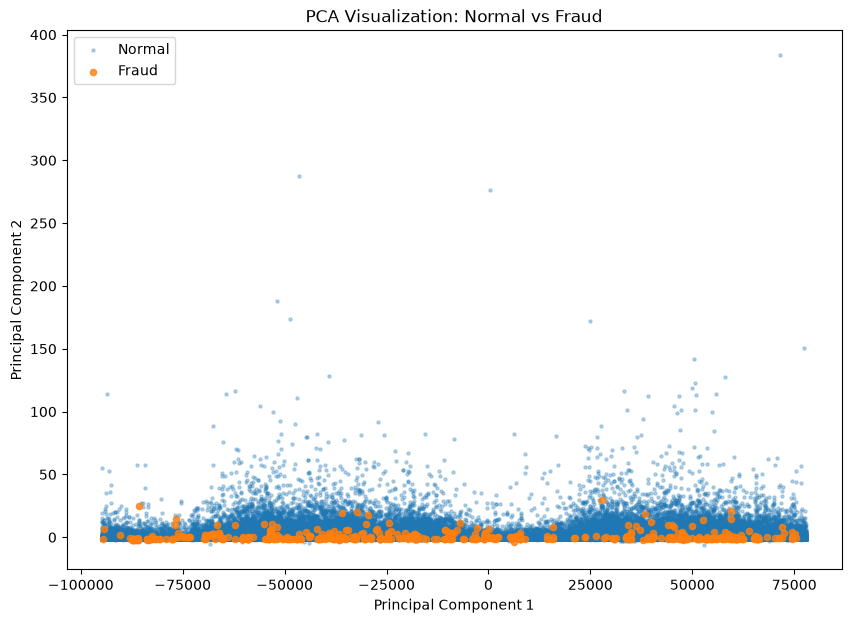

In [37]:
# ============================================
# ACTUAL NORMAL VS FRAUD - PCA
# ============================================

plt.figure(figsize=(10, 7))

plt.scatter(
    X_pca[y == 0, 0],
    X_pca[y == 0, 1],
    s=5,
    alpha=0.3,
    label="Normal"
)

plt.scatter(
    X_pca[y == 1, 0],
    X_pca[y == 1, 1],
    s=20,
    alpha=0.8,
    label="Fraud"
)

plt.title("PCA Visualization: Normal vs Fraud")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()

plt.show()

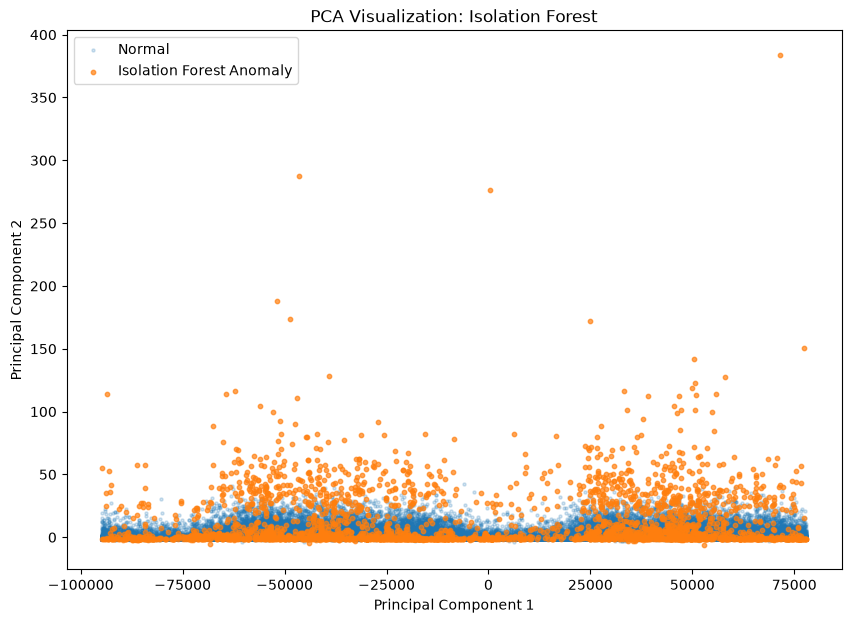

In [38]:
# ============================================
# ISOLATION FOREST ANOMALIES - PCA
# ============================================

plt.figure(figsize=(10, 7))

plt.scatter(
    X_pca[isolation_predictions == 0, 0],
    X_pca[isolation_predictions == 0, 1],
    s=5,
    alpha=0.2,
    label="Normal"
)

plt.scatter(
    X_pca[isolation_predictions == 1, 0],
    X_pca[isolation_predictions == 1, 1],
    s=10,
    alpha=0.7,
    label="Isolation Forest Anomaly"
)

plt.title("PCA Visualization: Isolation Forest")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()

plt.show()

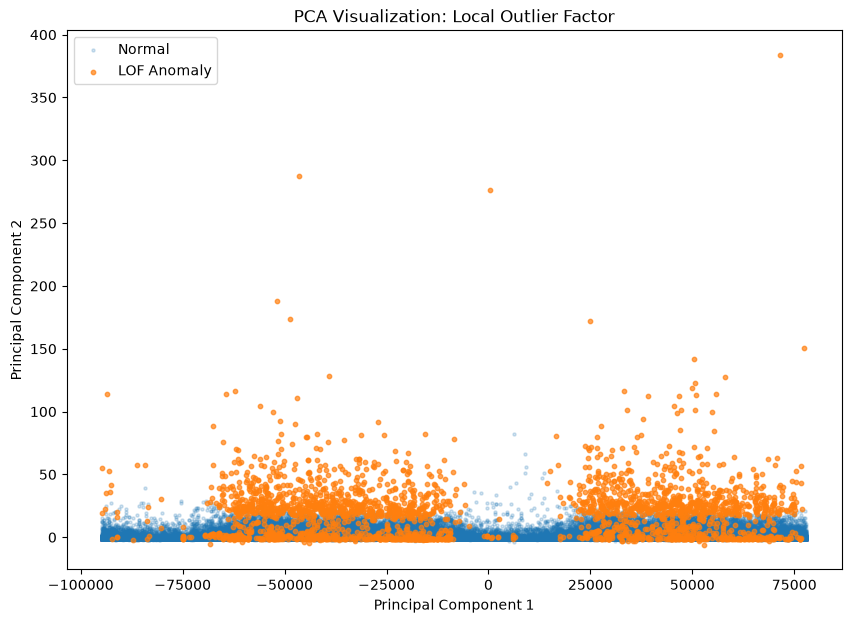

In [39]:
# ============================================
# LOF ANOMALIES - PCA
# ============================================

plt.figure(figsize=(10, 7))

plt.scatter(
    X_pca[lof_predictions == 0, 0],
    X_pca[lof_predictions == 0, 1],
    s=5,
    alpha=0.2,
    label="Normal"
)

plt.scatter(
    X_pca[lof_predictions == 1, 0],
    X_pca[lof_predictions == 1, 1],
    s=10,
    alpha=0.7,
    label="LOF Anomaly"
)

plt.title("PCA Visualization: Local Outlier Factor")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()

plt.show()

In [40]:
# ============================================
# MODEL PERFORMANCE COMPARISON
# ============================================

comparison = pd.DataFrame({
    "Model": ["Isolation Forest", "LOF"],
    "Precision": [precision_if, precision_lof],
    "Recall": [recall_if, recall_lof],
    "F1-Score": [f1_if, f1_lof]
})

comparison

,Model,Precision,Recall,F1-Score
0,Isolation Forest,0.087877,0.556911,0.151801
1,LOF,0.057459,0.317073,0.097287


In [41]:
# ============================================
# PRECISION-RECALL CURVE
# ============================================

# Get anomaly scores from Isolation Forest
# Higher score = more normal
if_scores = isolation_forest.decision_function(X)

# Convert so that higher value = more anomalous
if_anomaly_scores = -if_scores

# Calculate precision and recall at different thresholds
precision_values, recall_values, thresholds = precision_recall_curve(
    y,
    if_anomaly_scores
)

# Calculate F1-score
f1_values = (
    2 * precision_values * recall_values
    / (precision_values + recall_values + 1e-10)
)

# Find threshold giving maximum F1
best_index = np.argmax(f1_values)

best_precision = precision_values[best_index]
best_recall = recall_values[best_index]
best_f1 = f1_values[best_index]

print("ISOLATION FOREST - BEST F1 OPERATING POINT")
print("============================================")
print(f"Best Precision: {best_precision:.4f}")
print(f"Best Recall:    {best_recall:.4f}")
print(f"Best F1-Score:  {best_f1:.4f}")

ISOLATION FOREST - BEST F1 OPERATING POINT
Best Precision: 0.2151
Best Recall:    0.2541
Best F1-Score:  0.2330


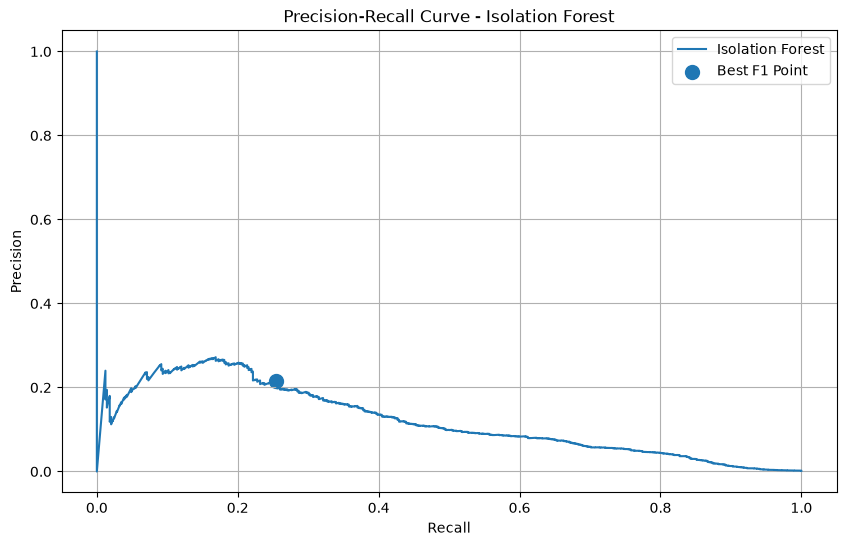

In [42]:
# ============================================
# PRECISION-RECALL CURVE
# ============================================

plt.figure(figsize=(10, 6))

plt.plot(
    recall_values,
    precision_values,
    label="Isolation Forest"
)

plt.scatter(
    best_recall,
    best_precision,
    s=100,
    label="Best F1 Point"
)

plt.title("Precision-Recall Curve - Isolation Forest")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.grid(True)

plt.show()

In [43]:
# ============================================
# CONTAMINATION PARAMETER TUNING
# ============================================

contamination_values = [0.005, 0.01, 0.015, 0.02, 0.03]

results = []

for contamination in contamination_values:

    print(f"Testing contamination = {contamination}")

    model = IsolationForest(
        n_estimators=100,
        contamination=contamination,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_normal)

    predictions = model.predict(X)

    # Convert -1 (anomaly) to 1 (fraud)
    predictions = np.where(predictions == -1, 1, 0)

    precision = precision_score(y, predictions, zero_division=0)
    recall = recall_score(y, predictions, zero_division=0)
    f1 = f1_score(y, predictions, zero_division=0)

    results.append({
        "Contamination": contamination,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    })

tuning_results = pd.DataFrame(results)

print("\nCONTAMINATION TUNING RESULTS")
print("============================")

tuning_results

Testing contamination = 0.005
Testing contamination = 0.01
Testing contamination = 0.015
Testing contamination = 0.02
Testing contamination = 0.03

CONTAMINATION TUNING RESULTS


,Contamination,Precision,Recall,F1-Score
0,0.005,0.127607,0.422764,0.196041
1,0.010,0.087877,0.556911,0.151801
2,0.015,0.071413,0.666667,0.129007
3,0.020,0.057507,0.705285,0.106344
4,0.030,0.044151,0.800813,0.083687


In [44]:
# ============================================
# BEST CONTAMINATION VALUE
# ============================================

best_result = tuning_results.loc[
    tuning_results["F1-Score"].idxmax()
]

print("BEST CONTAMINATION CONFIGURATION")
print("=================================")
print(f"Contamination: {best_result['Contamination']}")
print(f"Precision:     {best_result['Precision']:.4f}")
print(f"Recall:        {best_result['Recall']:.4f}")
print(f"F1-Score:      {best_result['F1-Score']:.4f}")

BEST CONTAMINATION CONFIGURATION
Contamination: 0.005
Precision:     0.1276
Recall:        0.4228
F1-Score:      0.1960


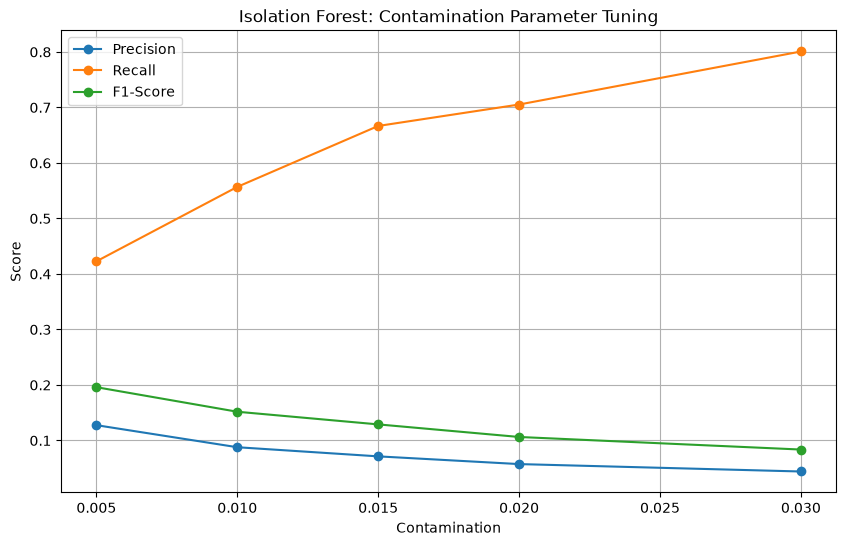

In [45]:
# ============================================
# CONTAMINATION TUNING VISUALIZATION
# ============================================

plt.figure(figsize=(10, 6))

plt.plot(
    tuning_results["Contamination"],
    tuning_results["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    tuning_results["Contamination"],
    tuning_results["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    tuning_results["Contamination"],
    tuning_results["F1-Score"],
    marker="o",
    label="F1-Score"
)

plt.xlabel("Contamination")
plt.ylabel("Score")
plt.title("Isolation Forest: Contamination Parameter Tuning")
plt.legend()
plt.grid(True)

plt.show()

In [46]:
# ============================================
# FINAL MODEL COMPARISON
# ============================================

final_comparison = pd.DataFrame({
    "Model": ["Isolation Forest", "LOF"],
    "Precision": [precision_if, precision_lof],
    "Recall": [recall_if, recall_lof],
    "F1-Score": [f1_if, f1_lof]
})

print("FINAL MODEL COMPARISON")
print("======================")

final_comparison


FINAL MODEL COMPARISON


,Model,Precision,Recall,F1-Score
0,Isolation Forest,0.087877,0.556911,0.151801
1,LOF,0.057459,0.317073,0.097287


In [2]:
# ============================================
# FINAL MODEL RECOMMENDATION
# ============================================

print("FINAL RECOMMENDATION")
print("====================")

print("Recommended Model: Isolation Forest")
print("Recommended Contamination: 0.005")
print("Precision: 0.1276")
print("Recall:    0.4228")
print("F1-Score:  0.1960")

print("\nReason:")
print("Isolation Forest achieved the highest F1-score among")
print("the tested contamination configurations and outperformed")
print("LOF in the initial model comparison.")

FINAL RECOMMENDATION
Recommended Model: Isolation Forest
Recommended Contamination: 0.005
Precision: 0.1276
Recall:    0.4228
F1-Score:  0.1960

Reason:
Isolation Forest achieved the highest F1-score among
the tested contamination configurations and outperformed
LOF in the initial model comparison.


In [4]:
# ============================================
# FINAL MODEL TRAINING AND SAVING
# SecurePay - Credit Card Fraud Detection
# ============================================

import pandas as pd
import numpy as np
import os
import joblib

from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import IsolationForest


# --------------------------------------------
# 1. LOAD DATASET
# --------------------------------------------

print("Loading dataset...")

df = pd.read_csv("../data/creditcard.csv")

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)


# --------------------------------------------
# 2. SEPARATE FEATURES AND TARGET
# --------------------------------------------

X = df.drop("Class", axis=1)
y = df["Class"]

print("\nFeatures shape:", X.shape)
print("Target shape:", y.shape)


# --------------------------------------------
# 3. ROBUST SCALING
# --------------------------------------------

scaler = RobustScaler()

# Scale only the Amount feature
X["Amount"] = scaler.fit_transform(
    X[["Amount"]]
)

print("\nAmount feature scaled successfully.")


# --------------------------------------------
# 4. CREATE FINAL ISOLATION FOREST MODEL
# --------------------------------------------

print("\nTraining final Isolation Forest model...")

final_model = IsolationForest(
    contamination=0.005,
    random_state=42,
    n_estimators=100
)


# --------------------------------------------
# 5. TRAIN MODEL
# --------------------------------------------

final_model.fit(X)

print("Model training completed successfully!")


# --------------------------------------------
# 6. CREATE MODELS DIRECTORY
# --------------------------------------------

os.makedirs("../models", exist_ok=True)


# --------------------------------------------
# 7. SAVE ISOLATION FOREST MODEL
# --------------------------------------------

model_path = "../models/isolation_forest_model.pkl"

joblib.dump(
    final_model,
    model_path
)

print("\nIsolation Forest model saved successfully!")
print("Model path:", model_path)


# --------------------------------------------
# 8. SAVE ROBUST SCALER
# --------------------------------------------

scaler_path = "../models/robust_scaler.pkl"

joblib.dump(
    scaler,
    scaler_path
)

print("RobustScaler saved successfully!")
print("Scaler path:", scaler_path)


# --------------------------------------------
# 9. VERIFY SAVED FILES
# --------------------------------------------

print("\n============================================")
print("FINAL MODEL FILES")
print("============================================")

print("Model exists:", os.path.exists(model_path))
print("Scaler exists:", os.path.exists(scaler_path))


# --------------------------------------------
# 10. FINAL INFORMATION
# --------------------------------------------

print("\n============================================")
print("FINAL MODEL INFORMATION")
print("============================================")

print("Model: Isolation Forest")
print("Contamination: 0.005")
print("Number of estimators: 100")
print("Random state: 42")

print("\nFinal model and scaler are ready for deployment! 🚀")

Loading dataset...
Dataset loaded successfully!
Dataset shape: (284807, 31)

Features shape: (284807, 30)
Target shape: (284807,)

Amount feature scaled successfully.

Training final Isolation Forest model...
Model training completed successfully!

Isolation Forest model saved successfully!
Model path: ../models/isolation_forest_model.pkl
RobustScaler saved successfully!
Scaler path: ../models/robust_scaler.pkl

FINAL MODEL FILES
Model exists: True
Scaler exists: True

FINAL MODEL INFORMATION
Model: Isolation Forest
Contamination: 0.005
Number of estimators: 100
Random state: 42

Final model and scaler are ready for deployment! 🚀
